# Modelo final - BETO baseline

In [1]:
!git clone https://github.com/camistrika/BETO_HUMOR.git
%cd BETO_HUMOR
!pip install -e . -q

Cloning into 'BETO_HUMOR'...
remote: Enumerating objects: 178, done.
remote: Counting objects: 100% (178/178), done.
remote: Compressing objects: 100% (101/101), done.
remote: Total 178 (delta 83), reused 152 (delta 68), pack-reused 0 (from 0)
Receiving objects: 100% (178/178), 3.42 MiB | 30.49 MiB/s, done.
Resolving deltas: 100% (83/83), done.
/content/BETO_HUMOR
  Preparing metadata (setup.py) ... done


In [1]:
!pip install -q torchao --upgrade
!pip install -q transformers peft datasets scikit-learn pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 104.7 MB/s eta 0:00:00


In [2]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
import shutil
import json
from google.colab import files

from betohumor.config import DataConfig, BetoConfig
from betohumor.utils import set_seed
from betohumor.dataset import load_and_split, HahaDataset
from betohumor.models.beto import build_beto
from betohumor.train import train_model
from betohumor.metrics import get_best_macro_f1_from_history, get_training_history
from betohumor.plots import plot_training_curves

In [3]:
%cd /content/BETO_HUMOR

/content/BETO_HUMOR


## 1. Mejor configuración (resultado del CV)
Completar con los valores reales que ganaron en `cross_validation_baseline.ipynb`.

In [4]:
BEST_LR = 5e-4
BEST_WD = 0.01

## 2. Datos: train + val combinados


In [5]:
data_config = DataConfig()
beto_config = BetoConfig()
set_seed(data_config.seed)

df_train, df_val, df_test = load_and_split(data_config)
df_combined = pd.concat([df_train, df_val]).reset_index(drop=True)

df_train_final, df_val_final = train_test_split(
    df_combined, test_size=0.05,
    stratify=df_combined[data_config.label_col],
    random_state=data_config.seed,
)

print(f'Train final: {len(df_train_final)} | Val: {len(df_val_final)}')

Train: 19197 | Val: 2397 | Test: 2400
Train final: 20514 | Val: 1080


## 3. Entrenar el modelo final

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(beto_config.base_model)

train_dataset = HahaDataset(df_train_final, tokenizer, data_config)
val_dataset   = HahaDataset(df_val_final,   tokenizer, data_config)

model = build_beto(beto_config)

trainer = train_model(
    model, train_dataset, val_dataset, beto_config,
    output_dir='results/final_beto',
    seed=data_config.seed,
    learning_rate=BEST_LR,
    weight_decay=BEST_WD,
)

## 4. Curva de entrenamiento

Macro F1: 0.8430


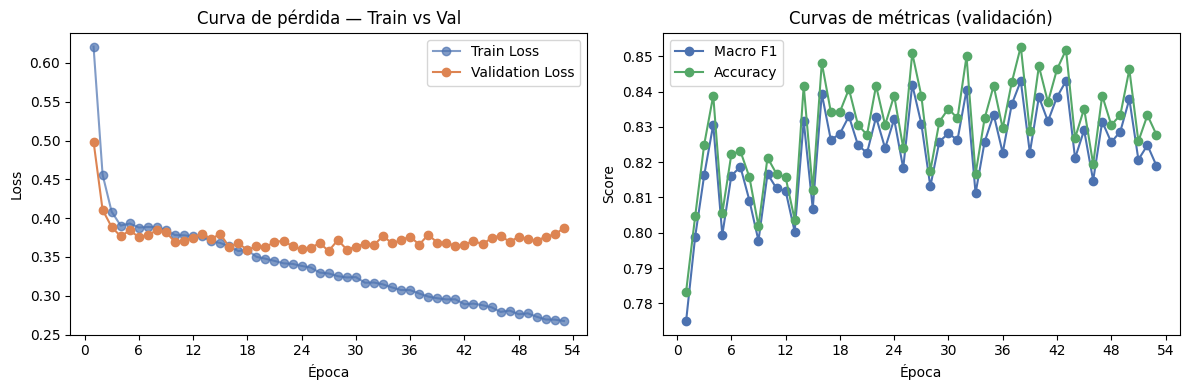

In [7]:
history = get_training_history(trainer)
macro_f1 = get_best_macro_f1_from_history(trainer)

print(f'Macro F1: {macro_f1:.4f}')
_ = plot_training_curves(history)

## 5. Guardar el modelo final e historial


In [ ]:
trainer.save_model('results/final_beto')
tokenizer.save_pretrained('results/final_beto')
print('Modelo final guardado')

In [10]:

with open('results/final_beto/training_history.json', 'w') as f:
    json.dump({
        'best_macro_f1': macro_f1,
        'train_epochs': history['train_epochs'],
        'train_loss': history['train_loss'],
        'eval_epochs': history['eval_epochs'],
        'eval_loss': history['eval_loss'],
        'macro_f1_por_epoca': history['macro_f1'],
        'accuracy_por_epoca': history['accuracy'],
    }, f, indent=2)
print('Historial guardado')

for folder in os.listdir('results/final_beto'):
    if folder.startswith('checkpoint'):
        shutil.rmtree(os.path.join('results/final_beto', folder))

shutil.make_archive('final_beto', 'zip', 'results/final_beto')
files.download('final_beto.zip')

Historial guardado


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>